## Problem Description -

Insurance companies take risks over customers. Risk management is a very important aspect of the insurance industry. Insurers consider every quantifiable factor to develop profiles of high and low insurance risks. Insurers collect vast amounts of information about policyholders and analyze the data.In this project I'll have to need to analyze the available data and predict whether to sanction the insurance or not using different machine learning classifer models.

## Dataset Description-
The dataset given consists of data corresponding to 50553 customers. Following are the features of the dataset:
- Target: Claim Status
- Name of agency (Agency)
- Type of travel insurance agencies (Agency.Type)
- Distribution channel of travel insurance agencies (Distribution.Channel)
- Name of the travel insurance products (Product.Name)
- Duration of travel (Duration)
- Destination of travel (Destination)
- Amount of sales of travel insurance policies (Net.Sales)
- The commission received for travel insurance agency (Commission)
- Gender of insured (Gender)
- Age of insured (Age)

#### Importing the Data

In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

#### Basic Data Overview

In [53]:
df = pd.read_csv('D:\Internship\ds-aiml-genai-internship\Data\TravelInsuranceClaimStatus.csv')

In [54]:
# Checking the distribution of the claims
df["Claim"].value_counts()

Claim
0    49830
1    12458
Name: count, dtype: int64

In [55]:
# Count with Percentage
df["Claim"].value_counts(normalize=True) * 100

Claim
0    79.999358
1    20.000642
Name: proportion, dtype: float64

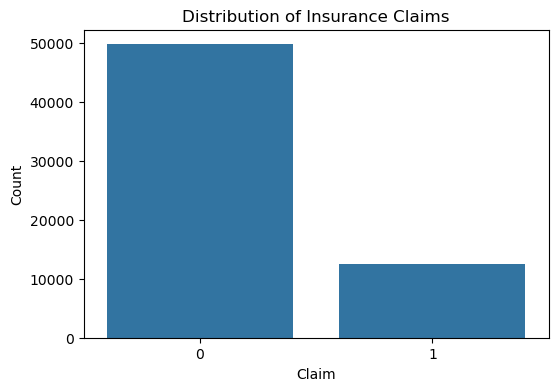

In [56]:
# Visualize the Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Claim", data=df)

plt.title("Distribution of Insurance Claims")
plt.xlabel("Claim")
plt.ylabel("Count")
plt.show()

In [57]:
#checking for the data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62288 entries, 0 to 62287
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    62288 non-null  int64  
 1   Age                   62288 non-null  int64  
 2   Agency                62288 non-null  object 
 3   Agency Type           62288 non-null  object 
 4   Commision (in value)  62288 non-null  float64
 5   Destination           62288 non-null  object 
 6   Distribution Channel  62288 non-null  object 
 7   Duration              62288 non-null  int64  
 8   Gender                22713 non-null  object 
 9   Net Sales             62288 non-null  float64
 10  Product Name          62288 non-null  object 
 11  Claim                 62288 non-null  int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 5.7+ MB


In [58]:
# Checking the weightage of null values.
df.isnull().sum()

ID                          0
Age                         0
Agency                      0
Agency Type                 0
Commision (in value)        0
Destination                 0
Distribution Channel        0
Duration                    0
Gender                  39575
Net Sales                   0
Product Name                0
Claim                       0
dtype: int64

In [59]:
# Check for unique Value in the DataFrame.
df.nunique()

ID                      50756
Age                        89
Agency                     16
Agency Type                 2
Commision (in value)      940
Destination               102
Distribution Channel        2
Duration                  443
Gender                      2
Net Sales                1037
Product Name               25
Claim                       2
dtype: int64

In [60]:
# get the summary of data
df.describe()

,ID,Age,Commision (in value),Duration,Net Sales,Claim
count,62288.000000,62288.000000,62288.000000,62288.000000,62288.000000,62288.000000
mean,32844.953458,39.666324,12.829703,60.958804,50.717064,0.200006
std,18065.417216,14.014652,23.498745,114.325330,63.166715,0.400008
min,0.000000,0.000000,0.000000,-2.000000,-389.000000,0.000000
25%,17579.000000,33.000000,0.000000,10.000000,20.000000,0.000000
50%,33446.500000,36.000000,1.880000,25.000000,29.700000,0.000000
75%,48532.250000,43.000000,14.440000,59.000000,58.000000,0.000000
max,63323.000000,118.000000,262.760000,4881.000000,682.000000,1.000000


In [61]:
# define a function to make age groups as children, adults and senior
def age_group(age):
    if age < 18:
        return "Children"
    elif age < 60:
        return "Adults"
    else:
        return "Senior"

In [62]:
# Write a function for data preprocessing to add column age group
def preprocess_data(df):
    def age_group(age):
        if age < 18:
            return "Children"
        elif age < 60:
            return "Adults"
        else:
            return "Senior"

    df["Age_Group"] = df["Age"].apply(age_group)

    return df

#### EXPLORATORY DATA ANALYSIS

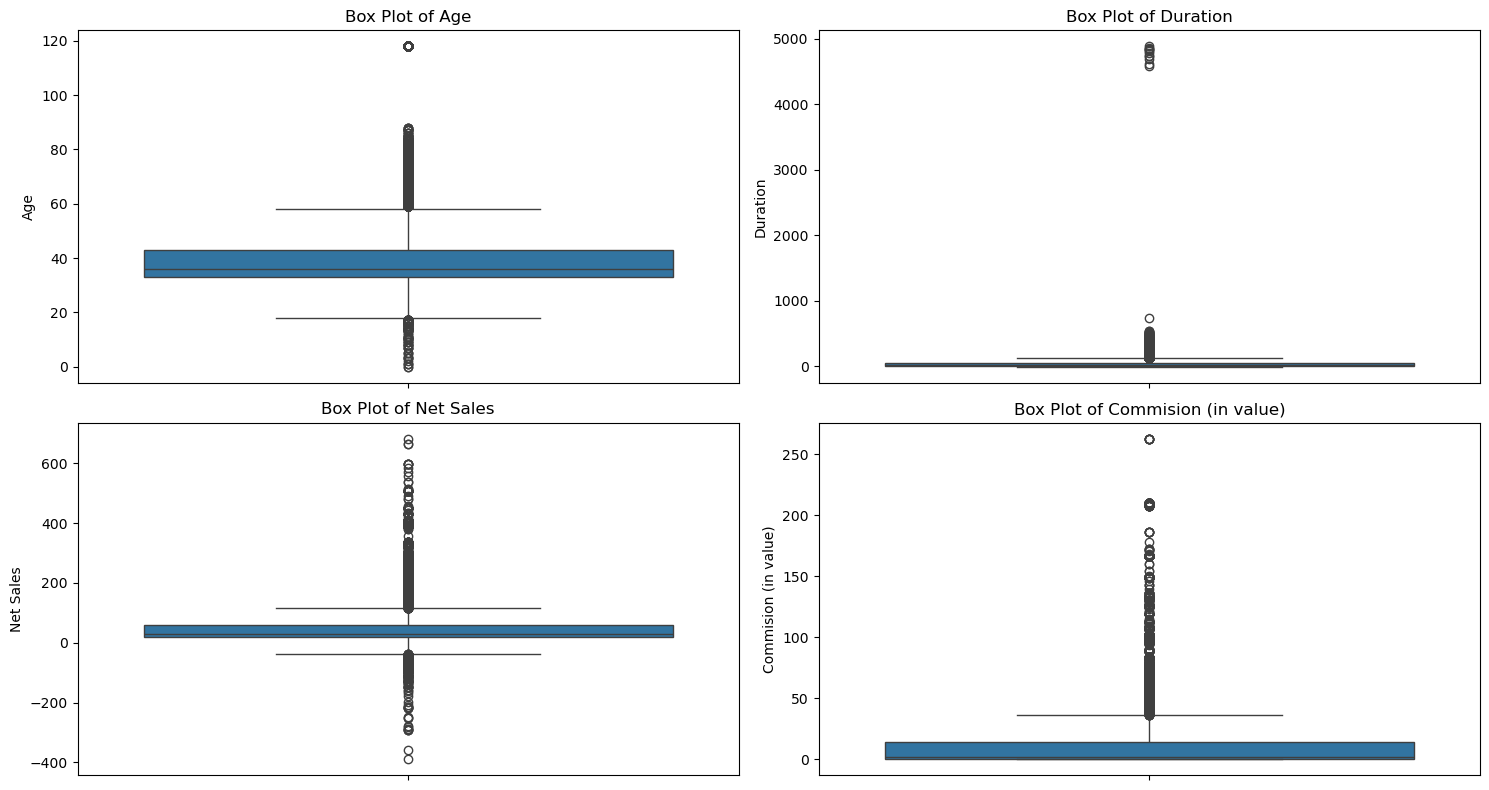

In [63]:
# box plots & histograms
num_cols = ["Age", "Duration", "Net Sales", "Commision (in value)"]

plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()

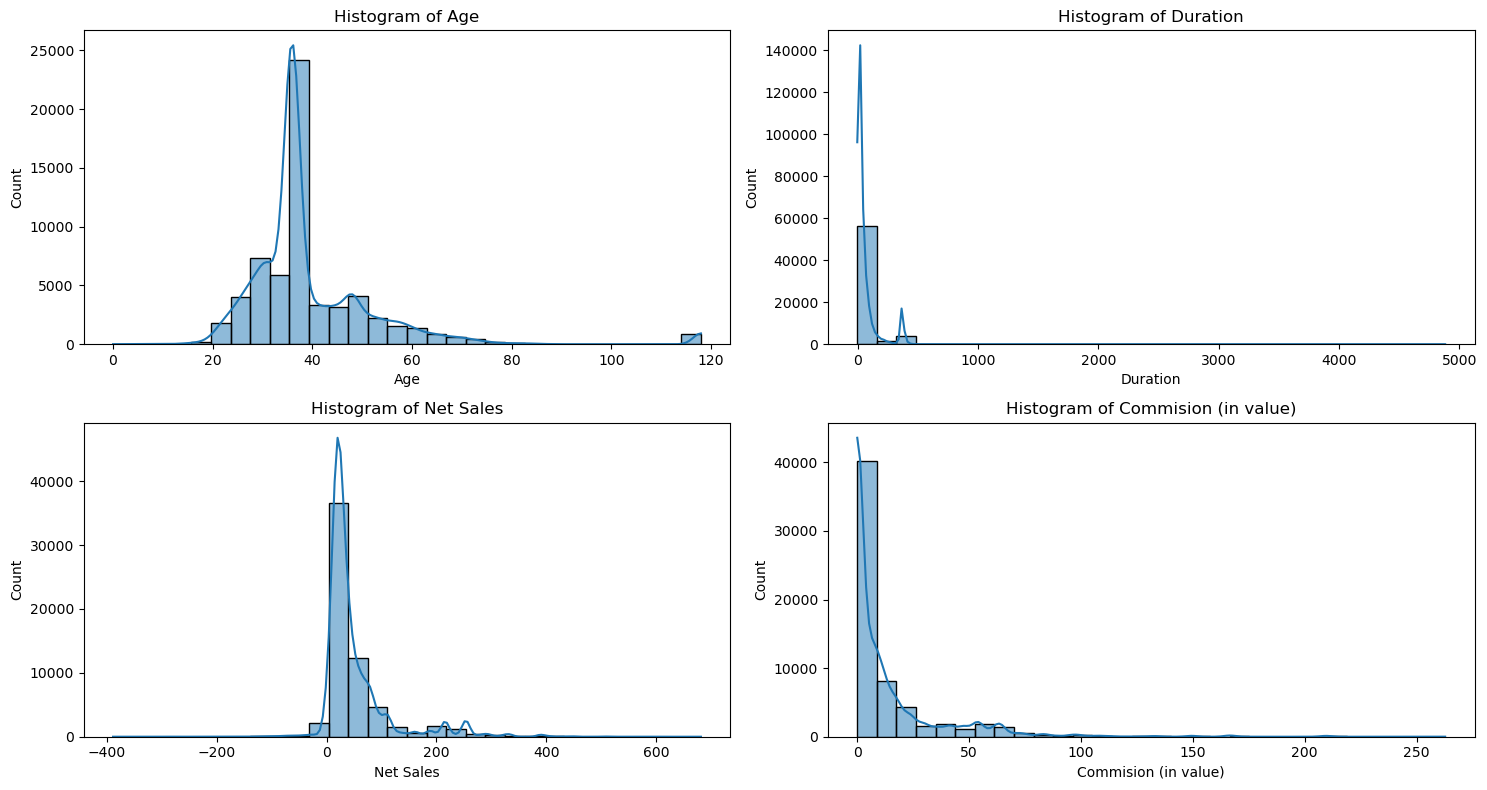

In [64]:
plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Histogram of {col}")

plt.tight_layout()
plt.show()

In [65]:
# Finding the Agencies with the Maximum Claims
agency_claims = (
    df[df["Claim"] == 1]
    .groupby("Agency")["Claim"]
    .count()
    .sort_values(ascending=False)
)

agency_claims

Agency
C2B    7414
EPX    2570
CWT    1160
LWC     458
JZI     418
KML     134
SSI      98
TTW      49
CCR      47
JWT      39
TST      22
CBH      14
CSR      13
ART      12
RAB      10
Name: Claim, dtype: int64

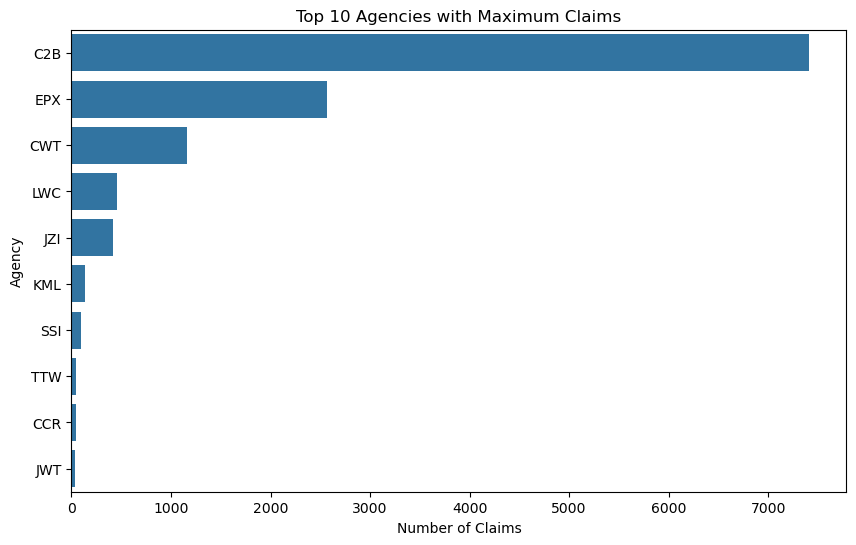

In [66]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=agency_claims.head(10).values,
    y=agency_claims.head(10).index
)

plt.title("Top 10 Agencies with Maximum Claims")
plt.xlabel("Number of Claims")
plt.ylabel("Agency")

plt.show()

In [67]:
# Agencies with the most number of net sales
agency_sales = (
    df.groupby("Agency")["Net Sales"]
    .sum()
    .sort_values(ascending=False)
)

agency_sales

Agency
C2B    1334783.53
EPX    1024034.00
CWT     375457.50
JZI     177362.00
LWC     124451.50
JWT      35089.00
KML      23329.00
TST      12930.00
TTW      12129.00
RAB      10628.00
ART       7580.45
CCR       6393.00
SSI       6210.53
ADM       3652.00
CBH       2657.00
CSR       2378.00
Name: Net Sales, dtype: float64

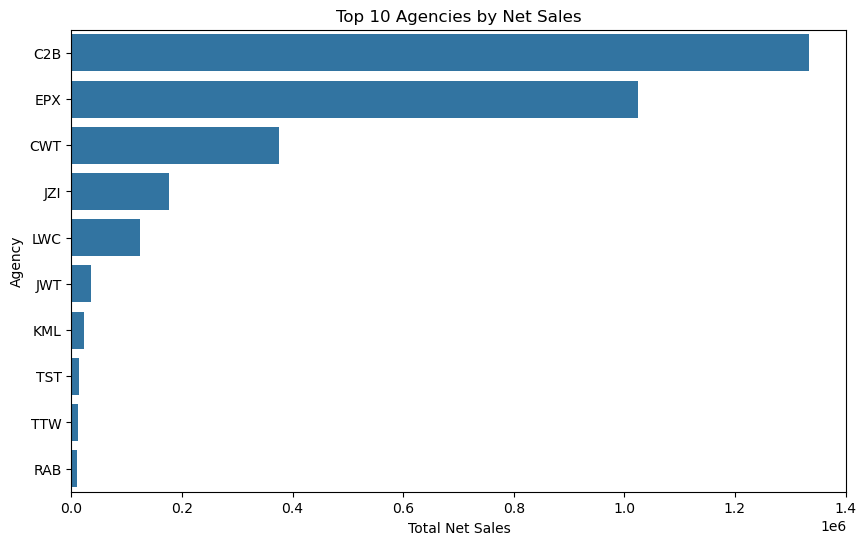

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=agency_sales.head(10).values,
    y=agency_sales.head(10).index
)

plt.title("Top 10 Agencies by Net Sales")
plt.xlabel("Total Net Sales")
plt.ylabel("Agency")

plt.show()

In [69]:
# claim status according to Agency Type
agency_type_claim = pd.crosstab(df["Agency Type"], df["Claim"])
agency_type_claim

Claim,0,1
Agency Type,,
Airlines,13481,7991
Travel Agency,36349,4467


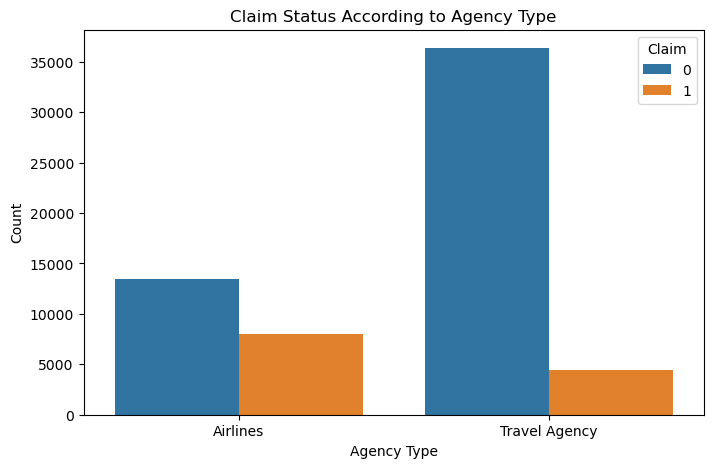

In [70]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Agency Type",
    hue="Claim",
    data=df
)

plt.title("Claim Status According to Agency Type")
plt.xlabel("Agency Type")
plt.ylabel("Count")

plt.show()

In [71]:
# net sales according to product name 
product_sales = (
    df.groupby("Product Name")["Net Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales

Product Name
Annual Silver Plan                      720709.98
2 way Comprehensive Plan                540984.00
Cancellation Plan                       404730.00
Rental Vehicle Excess Insurance         375457.50
Silver Plan                             214854.95
Bronze Plan                             212859.60
Annual Gold Plan                        144824.70
Basic Plan                              123388.00
Value Plan                              118597.00
1 way Comprehensive Plan                 78320.00
Annual Travel Protect Gold               49757.30
Gold Plan                                41534.30
Annual Travel Protect Silver             26372.45
Annual Travel Protect Platinum           24943.40
Travel Cruise Protect                    12930.00
Premier Plan                             12437.00
Single Trip Travel Protect Gold          11857.20
Comprehensive Plan                       10598.00
Individual Comprehensive Plan             9215.00
Ticket Protector                     

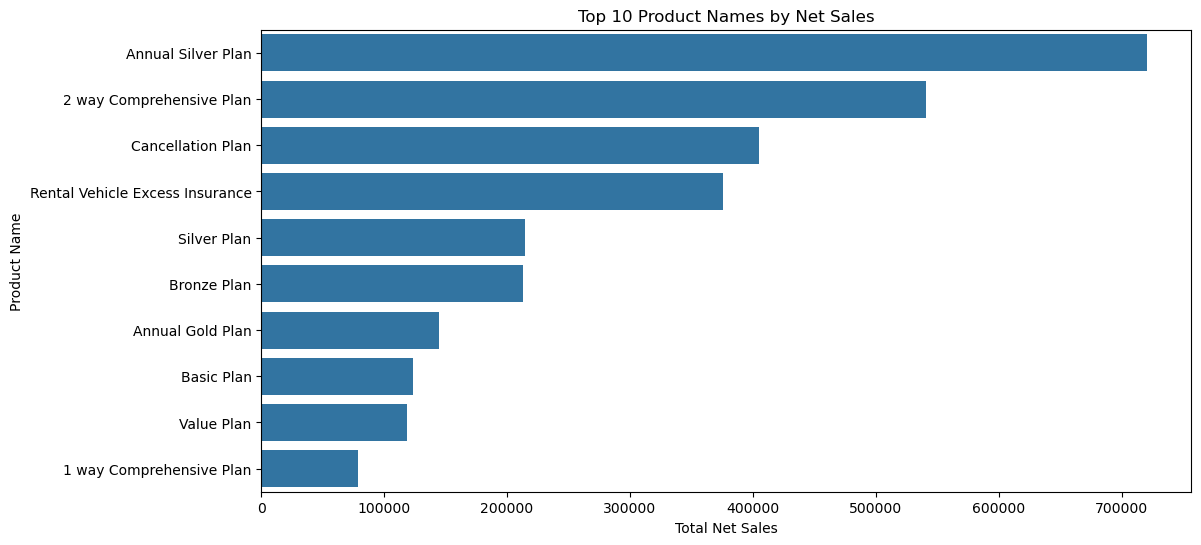

In [72]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=product_sales.head(10).values,
    y=product_sales.head(10).index
)

plt.title("Top 10 Product Names by Net Sales")
plt.xlabel("Total Net Sales")
plt.ylabel("Product Name")

plt.show()

In [73]:
print("Product with Highest Net Sales:", product_sales.idxmax())
print("Total Net Sales:", product_sales.max())

Product with Highest Net Sales: Annual Silver Plan
Total Net Sales: 720709.98


In [74]:
df.columns

Index(['ID', 'Age', 'Agency', 'Agency Type', 'Commision (in value)',
       'Destination', 'Distribution Channel', 'Duration', 'Gender',
       'Net Sales', 'Product Name', 'Claim'],
      dtype='object')

In [75]:
def age_group(age):
    if age < 18:
        return "Children"
    elif age < 60:
        return "Adults"
    else:
        return "Senior"

df["Age_Group"] = df["Age"].apply(age_group)

In [76]:
df[["Age", "Age_Group"]].head()

,Age,Age_Group
0,28,Adults
1,37,Adults
2,27,Adults
3,36,Adults
4,26,Adults


In [77]:
age_group_count = df.groupby("Age_Group")["Net Sales"].count()
print(age_group_count)

Age_Group
Adults      58001
Children      161
Senior       4126
Name: Net Sales, dtype: int64


In [78]:
# claim status according to age group
age_claim = pd.crosstab(df["Age_Group"], df["Claim"])
age_claim

Claim,0,1
Age_Group,,
Adults,46485,11516
Children,97,64
Senior,3248,878


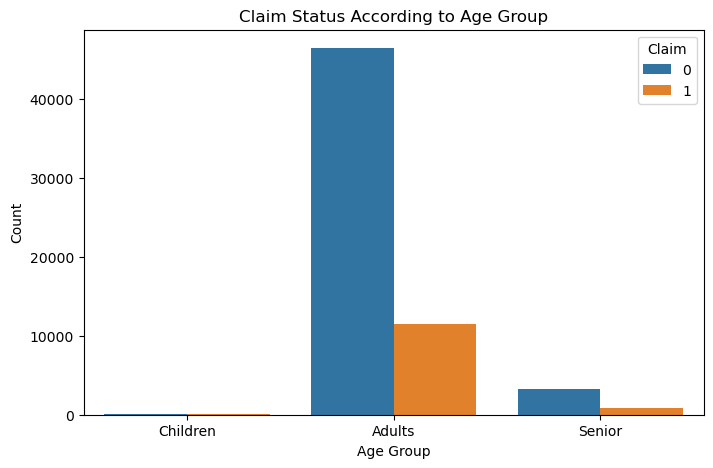

In [79]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Age_Group",
    hue="Claim",
    data=df,
    order=["Children", "Adults", "Senior"]
)

plt.title("Claim Status According to Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

#### Data Preprocessing

In [80]:
# Check for null & missing values and handle them appropriately.
# Check missing values in each column
df.isnull().sum()

ID                          0
Age                         0
Agency                      0
Agency Type                 0
Commision (in value)        0
Destination                 0
Distribution Channel        0
Duration                    0
Gender                  39575
Net Sales                   0
Product Name                0
Claim                       0
Age_Group                   0
dtype: int64

In [81]:
# Total missing values in the dataset
df.isnull().sum().sum()

np.int64(39575)

In [82]:
# Percentage of missing values
(df.isnull().sum() / len(df)) * 100

ID                       0.000000
Age                      0.000000
Agency                   0.000000
Agency Type              0.000000
Commision (in value)     0.000000
Destination              0.000000
Distribution Channel     0.000000
Duration                 0.000000
Gender                  63.535512
Net Sales                0.000000
Product Name             0.000000
Claim                    0.000000
Age_Group                0.000000
dtype: float64

In [83]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 39575


In [84]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [85]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [86]:
# Drop rows/columns if necessary.
# Drop the Gender column
df.drop("Gender", axis=1, inplace=True)

In [87]:
print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


In [88]:
# Normalize or standardize numerical variables.
from sklearn.preprocessing import StandardScaler

# Numerical columns
num_cols = ["Age", "Duration", "Net Sales", "Commision (in value)"]

# Initialize scaler
scaler = StandardScaler()

# Standardize numerical columns
df[num_cols] = scaler.fit_transform(df[num_cols])

# Display first five rows
df[num_cols].head()

,Age,Duration,Net Sales,Commision (in value)
0,-0.832444,-0.235810,0.978101,0.651116
1,-0.190254,-0.069616,-0.217158,0.005119
2,-0.903799,-0.288292,-0.597108,-0.545978
3,-0.261609,-0.524462,-0.264652,-0.545978
4,-0.975153,-0.244557,-0.175997,0.465148


In [89]:
df[num_cols].describe().round(2)

,Age,Duration,Net Sales,Commision (in value)
count,62288.00,62288.00,62288.00,62288.00
mean,-0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00
min,-2.83,-0.55,-6.96,-0.55
25%,-0.48,-0.45,-0.49,-0.55
50%,-0.26,-0.31,-0.33,-0.47
75%,0.24,-0.02,0.12,0.07
max,5.59,42.16,9.99,10.64


In [90]:
# Convert categorical variables into numerical variables.
df.select_dtypes(include="object").columns

Index(['Agency', 'Agency Type', 'Destination', 'Distribution Channel',
       'Product Name', 'Age_Group'],
      dtype='object')

In [91]:
# Convert categorical variables into numerical variables
df = pd.get_dummies(
    df,
    columns=[
        "Agency",
        "Agency Type",
        "Destination",
        "Distribution Channel",
        "Product Name",
        "Age_Group"
    ],
    drop_first=True
)

In [92]:
df.head()

,ID,Age,Commision (in value),Duration,Net Sales,Claim,Agency_ART,Agency_C2B,Agency_CBH,Agency_CCR,...,Product Name_Silver Plan,Product Name_Single Trip Travel Protect Gold,Product Name_Single Trip Travel Protect Platinum,Product Name_Single Trip Travel Protect Silver,Product Name_Spouse or Parents Comprehensive Plan,Product Name_Ticket Protector,Product Name_Travel Cruise Protect,Product Name_Value Plan,Age_Group_Children,Age_Group_Senior
0,45341,-0.832444,0.651116,-0.235810,0.978101,1,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False
1,12958,-0.190254,0.005119,-0.069616,-0.217158,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,18233,-0.903799,-0.545978,-0.288292,-0.597108,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,31742,-0.261609,-0.545978,-0.524462,-0.264652,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,14381,-0.975153,0.465148,-0.244557,-0.175997,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [93]:
df.dtypes

ID                                      int64
Age                                   float64
Commision (in value)                  float64
Duration                              float64
Net Sales                             float64
                                       ...   
Product Name_Ticket Protector            bool
Product Name_Travel Cruise Protect       bool
Product Name_Value Plan                  bool
Age_Group_Children                       bool
Age_Group_Senior                         bool
Length: 150, dtype: object

In [94]:
print(df.shape)

(62288, 150)


In [95]:
# Split the data into training (70%) and testing (30%) sets using train_test_split() from sklearn.
# Features (X) and Target (y)
X = df.drop("Claim", axis=1)
y = df["Claim"]

In [96]:
from sklearn.model_selection import train_test_split

# Split data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [97]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (43601, 149)
X_test shape : (18687, 149)
y_train shape: (43601,)
y_test shape : (18687,)


#### Build Binary Classification Models

In [98]:
# Train the following binary classification algorithms:

# Logistic Regression
# Decision Tree
# Random Forest
# Support Vector Machine (SVM)
# K Nearest Neighbors (KNN)
# Random Forest


In [99]:
X_train.head()

,ID,Age,Commision (in value),Duration,Net Sales,Agency_ART,Agency_C2B,Agency_CBH,Agency_CCR,Agency_CSR,...,Product Name_Silver Plan,Product Name_Single Trip Travel Protect Gold,Product Name_Single Trip Travel Protect Platinum,Product Name_Single Trip Travel Protect Silver,Product Name_Spouse or Parents Comprehensive Plan,Product Name_Ticket Protector,Product Name_Travel Cruise Protect,Product Name_Value Plan,Age_Group_Children,Age_Group_Senior
46558,24129,0.594645,-0.498316,-0.489474,-0.739748,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
21190,48346,-0.903799,-0.545978,0.560171,-0.628771,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
44490,24850,-0.261609,-0.545978,-0.471980,0.463585,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1400,44213,0.095164,-0.158721,-0.157086,-0.391302,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13620,30739,-0.261609,-0.545978,0.341495,0.685223,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [100]:
print(X_train[:5])

          ID       Age  Commision (in value)  Duration  Net Sales  Agency_ART  \
46558  24129  0.594645             -0.498316 -0.489474  -0.739748       False   
21190  48346 -0.903799             -0.545978  0.560171  -0.628771       False   
44490  24850 -0.261609             -0.545978 -0.471980   0.463585       False   
1400   44213  0.095164             -0.158721 -0.157086  -0.391302       False   
13620  30739 -0.261609             -0.545978  0.341495   0.685223       False   

       Agency_C2B  Agency_CBH  Agency_CCR  Agency_CSR  ...  \
46558       False       False       False       False  ...   
21190       False       False       False       False  ...   
44490       False       False       False       False  ...   
1400        False       False       False       False  ...   
13620       False       False       False       False  ...   

       Product Name_Silver Plan  Product Name_Single Trip Travel Protect Gold  \
46558                     False                            

In [101]:
from sklearn.preprocessing import StandardScaler

# Numerical columns only
num_cols = ["Age", "Duration", "Net Sales", "Commision (in value)"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [102]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    solver="saga",
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

e:\App\Anaconda\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,5000
,multi_class,'deprecated'


In [103]:
print(X_train.shape)

(43601, 149)


In [104]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt = DecisionTreeClassifier(
    random_state=42
)

# Train model
dt.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [105]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [106]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn = KNeighborsClassifier(
    n_neighbors=5
)

# Train model
knn.fit(X_train, y_train)

print("KNN trained successfully.")

KNN trained successfully.


In [107]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm.fit(X_train, y_train)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


#### Model Evaluation

In [108]:
# Evaluate each model using:

# Accuracy
# Precision
# Recall
# F1-Score
# ROC-AUC Score
# Confusion Matrix

In [109]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [110]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn
}

for name, model in models.items():

    # Prediction
    y_pred = model.predict(X_test)

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = "Not Available"

    print("="*60)
    print(name)
    print("="*60)

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    print("ROC-AUC  :", roc_auc)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy : 0.8008776154545941
Precision: 0.6976744186046512
Recall   : 0.008025682182985553
F1 Score : 0.015868817773075906
ROC-AUC  : 0.42451495777636117

Confusion Matrix
[[14936    13]
 [ 3708    30]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     14949
           1       0.70      0.01      0.02      3738

    accuracy                           0.80     18687
   macro avg       0.75      0.50      0.45     18687
weighted avg       0.78      0.80      0.71     18687

Decision Tree
Accuracy : 0.9783806924599989
Precision: 0.90246257846451
Recall   : 1.0
F1 Score : 0.9487309644670051
ROC-AUC  : 0.9864873904609004

Confusion Matrix
[[14545   404]
 [    0  3738]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     14949
           1       0.90      1.00      0.95      3738

    accuracy                           0.98

In [111]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = None

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.993953,0.970657,1.000000,0.985110,0.999927
1,Decision Tree,0.978381,0.902463,1.000000,0.948731,0.986487
4,KNN,0.945631,0.786526,0.999465,0.880302,0.987729
3,SVM,0.824691,0.645649,0.273943,0.384673,0.802004
0,Logistic Regression,0.800878,0.697674,0.008026,0.015869,0.424515


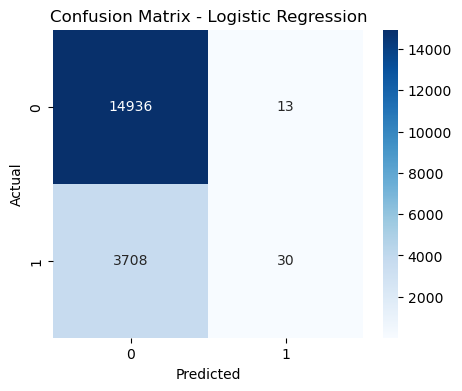

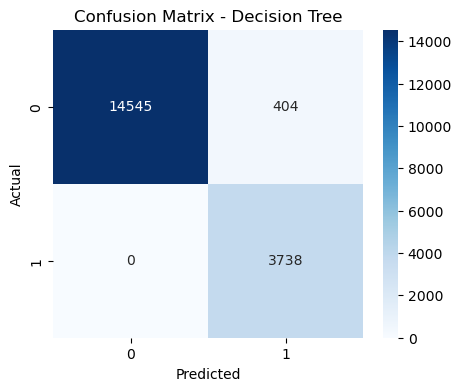

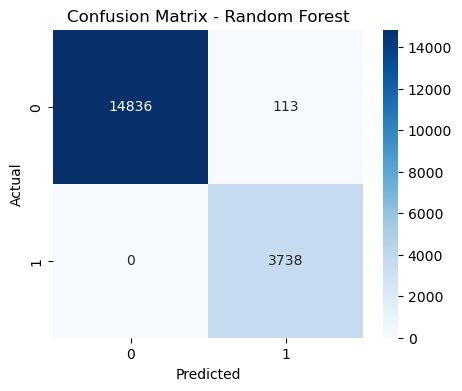

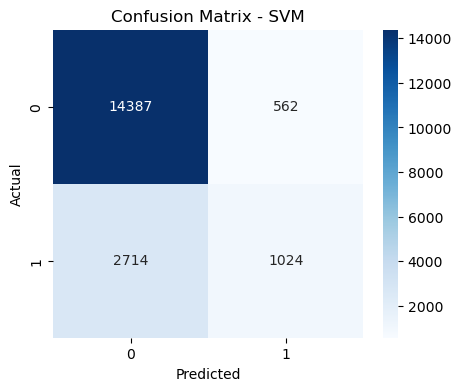

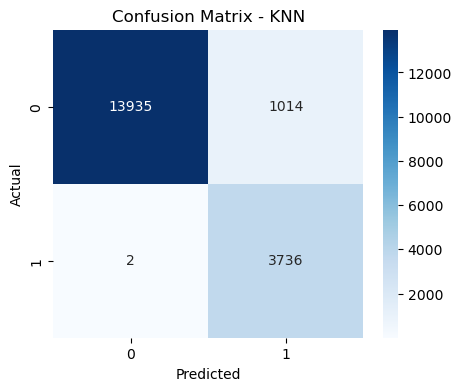

In [112]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

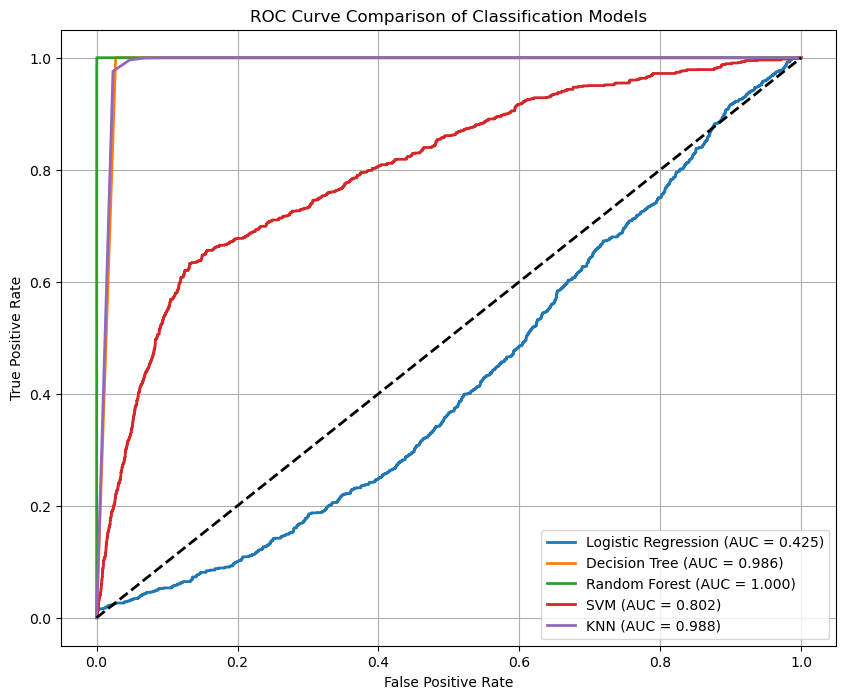

In [113]:
# Plot the ROC curves for all models on a single graph.
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "SVM": svm,
    "KNN": knn
}

for name, model in models.items():

    # Get prediction scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_score)

    # Compute AUC
    auc = roc_auc_score(y_test, y_score)

    # Plot ROC curve
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

# Random classifier line
plt.plot([0, 1], [0, 1], "k--", linewidth=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Classification Models")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

#### Hyperparameter Tuning

In [114]:
# Perform hyperparameter tuning for at least two models using GridSearchCV.
from sklearn.model_selection import GridSearchCV

In [115]:
from sklearn.ensemble import RandomForestClassifier

# Parameter Grid
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid Search
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Train
rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best Accuracy:", rf_grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Accuracy: 0.9910552588973782


In [116]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))

Test Accuracy: 0.9939530154652967


In [117]:
from sklearn.neighbors import KNeighborsClassifier

knn_params = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best Accuracy:", knn_grid.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best Accuracy: 0.9618357513078732


In [118]:
best_knn = knn_grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred_knn))

Test Accuracy: 0.9658051051533152


In [119]:
print("Random Forest Test Accuracy:",
      accuracy_score(y_test, best_rf.predict(X_test)))

print("KNN Test Accuracy:",
      accuracy_score(y_test, best_knn.predict(X_test)))

Random Forest Test Accuracy: 0.9939530154652967
KNN Test Accuracy: 0.9658051051533152


In [120]:
best_params = pd.DataFrame({
    "Model": ["Random Forest", "KNN"],
    "Best Parameters": [
        rf_grid.best_params_,
        knn_grid.best_params_
    ],
    "Best CV Accuracy": [
        rf_grid.best_score_,
        knn_grid.best_score_
    ]
})

best_params

,Model,Best Parameters,Best CV Accuracy
0,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.991055
1,KNN,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",0.961836


In [121]:
# Identify the best parameters and retrain the models.
# Best Parameters
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [122]:
from sklearn.ensemble import RandomForestClassifier

# Retrain Random Forest
best_rf = RandomForestClassifier(
    **rf_grid.best_params_,
    random_state=42
)

best_rf.fit(X_train, y_train)

print("Random Forest retrained successfully.")

Random Forest retrained successfully.


In [123]:
# Best Parameters
print("Best KNN Parameters:")
print(knn_grid.best_params_)

Best KNN Parameters:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [124]:
from sklearn.neighbors import KNeighborsClassifier

# Retrain KNN
best_knn = KNeighborsClassifier(
    **knn_grid.best_params_
)

best_knn.fit(X_train, y_train)

print("KNN retrained successfully.")

KNN retrained successfully.


In [125]:
from sklearn.metrics import accuracy_score, classification_report

# Random Forest
rf_pred = best_rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9939530154652967
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     14949
           1       0.97      1.00      0.99      3738

    accuracy                           0.99     18687
   macro avg       0.99      1.00      0.99     18687
weighted avg       0.99      0.99      0.99     18687



In [126]:
# KNN
knn_pred = best_knn.predict(X_test)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.9658051051533152
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     14949
           1       0.85      1.00      0.92      3738

    accuracy                           0.97     18687
   macro avg       0.93      0.98      0.95     18687
weighted avg       0.97      0.97      0.97     18687



In [127]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Random Forest,0.993953
1,KNN,0.965805
